In [ ]:
# A different sim
import numpy as np
import pandas as pd
def run (random, /, *args, strict=False, **kwargs):
  ts = pd.Series(random(*args, **kwargs))
  A, B = np.log(ts.mean()), np.log(ts).mean()
  return A, B, A>B or not strict and np.abs(A-B) <1e-9

size=10000
strict=False
print(run(np.random.lognormal, 10, size=size, strict=strict)[-1])

True


#Todo:
1. Monte Carlo
  - Assumption of Multivariate Normal Distribution and Revise some LA
2. Python OOP Revise
3. Pair trading set up
4. Quaterlly earnings charter
5. If given a company, get sector statistics and compare

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pandas_datareader.data as web
import datetime as dt
import yfinance as yf

import csv

In [ ]:
startdate = dt.datetime(2024, 9, 1)
enddate = dt.datetime(2025, 1, 1)
df = yf.download(['XOM', 'CVX'], start=startdate, end=enddate)

[*********************100%***********************]  2 of 2 completed


In [ ]:
df.head()

Price            Close                    High                     Low  \
Ticker             CVX         XOM         CVX         XOM         CVX   
Date                                                                     
2024-09-03  143.199249  114.528900  144.298041  115.143842  142.823082   
2024-09-04  140.635406  113.130394  144.060459  115.203364  140.239437   
2024-09-05  139.506897  112.247643  141.724283  114.340446  139.180243   
2024-09-06  137.160843  111.721962  140.674999  113.249412  136.477808   
2024-09-09  138.883270  114.072655  140.585903  115.203363  137.141033   

Price                         Open               Volume            
Ticker             XOM         CVX         XOM      CVX       XOM  
Date                                                               
2024-09-03  113.110555  144.080262  114.895880  7944700  15725100  
2024-09-04  113.051052  143.179447  114.350373  9820700  12620600  
2024-09-05  112.148459  141.724283  114.132159  9371100  17200800  
2024-09-06  110.819383  139.645507  112.664216  7836400  13467700  
2024-09-09  111.741809  137.240029  111.950097  9892300  21645300

In [ ]:
def get_data(tickers, startdate, enddate):
  stockData = yf.download(tickers, start=startdate, end=enddate)
  returns = stockData['Close'].pct_change()
  meanReturns = returns.mean()
  covMatrix = returns.cov()
  return meanReturns, covMatrix

enddate = dt.datetime(2025, 1, 1)
startdate = enddate - dt.timedelta(days = 365)
tickers = ['CARM', 'AKRO', 'ZNTL', 'AVNS']

meanRet, covMat = get_data(tickers, startdate, enddate)

[*********************100%***********************]  4 of 4 completed


In [ ]:
tickers = ["HDFCBANK.NS", "RELIANCE.NS", "ICICIBANK.NS", "INFY.NS", "BHARTIARTL.NS", "TCS.NS"]
stockData = yf.download(tickers, start=dt.datetime(2008, 1, 1), end = dt.datetime(2020, 12, 30))
stockData.head()

[*********************100%***********************]  6 of 6 completed


Price              Close                                                   \
Ticker     BHARTIARTL.NS HDFCBANK.NS ICICIBANK.NS     INFY.NS RELIANCE.NS   
Date                                                                        
2008-01-01    404.155182  152.192673   178.727158  150.644165  265.607269   
2008-01-02    403.591339  150.943130   184.327087  150.769211  266.866180   
2008-01-03    396.427887  149.103973   178.756195  147.384384  270.778198   
2008-01-04    396.114716  149.279953   187.098038  146.164139  279.105591   
2008-01-07    391.394806  145.672012   198.188889  141.157974  281.646790   

Price                           High                                       \
Ticker          TCS.NS BHARTIARTL.NS HDFCBANK.NS ICICIBANK.NS     INFY.NS   
Date                                                                        
2008-01-01  187.807755    417.688287  153.028652   180.363521  153.382209   
2008-01-02  186.997467    410.462313  152.659091   189.047090  151.722130   
2008-01-03  180.060699    403.006487  150.476742   183.985280  154.968977   
2008-01-04  179.018829    400.521316  150.828714   189.090761  150.691614   
2008-01-07  173.747360    395.884937  147.695971   200.719794  145.741504   

Price       ...         Open                                      \
Ticker      ... ICICIBANK.NS     INFY.NS RELIANCE.NS      TCS.NS   
Date        ...                                                    
2008-01-01  ...   180.363521  152.347358  269.500593  191.805929   
2008-01-02  ...   181.527090  150.915811  266.236736  188.778395   
2008-01-03  ...   182.123465  154.968977  265.957028  183.453365   
2008-01-04  ...   179.141684  150.691614  270.806081  180.060668   
2008-01-07  ...   186.181625  144.016752  277.408452  178.092830   

Price             Volume                                                 \
Ticker     BHARTIARTL.NS HDFCBANK.NS ICICIBANK.NS   INFY.NS RELIANCE.NS   
Date                                                                      
2008-01-01       2945314     1310520      4022843   2001624    10540548   
2008-01-02       5287686     6239750     13343407   6155056    27276294   
2008-01-03       5097441     7018640     13949831  12425960    30204199   
2008-01-04       4499385     3729820     14119715   6166320    35463186   
2008-01-07       5724909     6322460     40102892  13254200    27412209   

Price                
Ticker       TCS.NS  
Date                 
2008-01-01   928388  
2008-01-02  2864924  
2008-01-03  5168280  
2008-01-04  2318868  
2008-01-07  3647344  

[5 rows x 30 columns]

In [9]:
stockData['Close']['BHARTIARTL.NS']

Date
2008-01-01    404.155182
2008-01-02    403.591339
2008-01-03    396.427887
2008-01-04    396.114716
2008-01-07    391.394806
                 ...    
2020-12-22    483.974304
2020-12-23    490.649109
2020-12-24    500.419586
2020-12-28    504.579224
2020-12-29    503.273285
Name: BHARTIARTL.NS, Length: 3200, dtype: float64

In [7]:
stockData['Close']['BHARTIARTL.NS'].to_csv('BHARTIARTL.NS')
stockData['Close']['HDFCBANK.NS'].to_csv('HDFCBANK.NS')
stockData['Close']['ICICIBANK.NS'].to_csv('ICICIBANK.NS')
stockData['Close']['INFY.NS'].to_csv('INFY.NS')
stockData['Close']['RELIANCE.NS'].to_csv('RELIANCE.NS')
stockData['Close']['TCS.NS'].to_csv('TCS.NS')


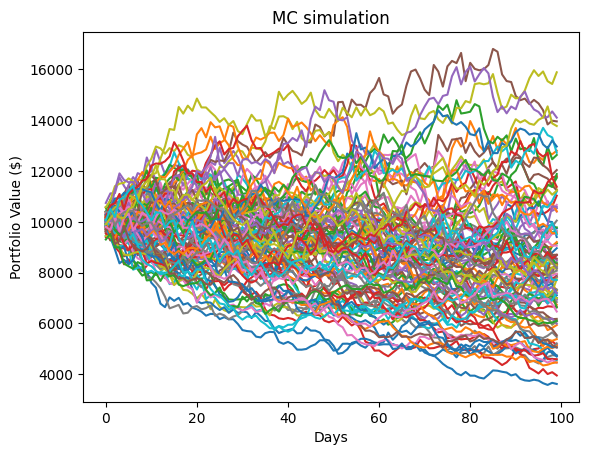

In [ ]:
weights = np.random.random(len(meanRet))
weights /= np.sum(weights)

# Monte Carlo
mc_sims = 100
T = 100 # days

meanMatrix = np.full(shape = (T, len(weights)), fill_value = meanRet).T
portfolio_sim = np.full(shape=(T, mc_sims), fill_value=0.0)
initialPortfolio = 10000

# MC loops
for i in range(0, mc_sims):
  Z = np.random.normal(size=(T, len(weights)))
  L = np.linalg.cholesky(covMat)
  dailyReturns = meanMatrix + np.inner(L, Z)
  portfolio_sim[:, i] = np.cumprod(np.inner(weights, dailyReturns.T) + 1)*initialPortfolio

plt.plot(portfolio_sim)
plt.ylabel("Portfolio Value ($)")
plt.xlabel('Days')
plt.title('MC simulation')
plt.show()


In [21]:
import os 
# print(os.getcwd())
hdfc = pd.read_csv('./workspace/notebooks/HDFCBANK.csv')

# Assignment code just for kicks

In [29]:
arr_hdfc = np.array(hdfc)
print(arr_hdfc)

[['2008-01-01' 152.1926727294922]
 ['2008-01-02' 150.94313049316406]
 ['2008-01-03' 149.10397338867188]
 ...
 ['2020-12-24' 1341.18603515625]
 ['2020-12-28' 1356.3057861328125]
 ['2020-12-29' 1370.08154296875]]


In [ ]:
# Feel free to modify the code to facilitate your implementation, e.g., add or modify functions, import other modules.
import argparse
import numpy as np
from queue import PriorityQueue

class Puzzle(object):
    def __init__(self, file_path=None, puzzle=None):
        self.size = 3
        self.goal_puzzle = np.array([[1, 2, 3],[8, 0, 4],[7, 6, 5]])

        if puzzle is not None:
            self.puzzle = puzzle
        elif file_path is not None:
            self.puzzle = self.read_puzzle(file_path)
            assert self.is_solvable(self.puzzle), '8-puzzle has an unsolvable initial state.'
        else:
            self.puzzle = self.make_puzzle()

    def make_puzzle(self):
        tiles = range(self.size ** 2)
        tiles = list(tiles)
        np.random.shuffle(tiles)

        while not self.is_solvable(np.array(tiles).reshape((self.size, self.size))):
            np.random.shuffle(tiles)

        return np.array(tiles).reshape((self.size, self.size))

    def read_puzzle(self, file_path):
        with open(file_path, 'r') as file:
            puzzle = np.array([list(map(int, line.strip().split())) for line in file.readlines()])
            assert puzzle.shape[0]==self.size and puzzle.shape[1]==self.size, "8-puzzle should have a 3 * 3 board."
        return puzzle

    def is_solvable(self, puzzle):
        # Based on http://math.stackexchange.com/questions/293527/how-to-check-if-a-8-puzzle-is-solvable
        goal_puzzle = self.goal_puzzle.flatten()
        goal_inversions = 0
        for i in range(len(goal_puzzle)):
            for j in range(i+1, len(goal_puzzle)):
                if goal_puzzle[i] > goal_puzzle[j] and goal_puzzle[i] != 0 and goal_puzzle[j] != 0:
                    goal_inversions += 1

        puzzle = puzzle.flatten()
        inversions = 0
        for i in range(len(puzzle)):
            for j in range(i+1, len(puzzle)):
                if puzzle[i] > puzzle[j] and puzzle[i] != 0 and puzzle[j] != 0:
                    inversions += 1

        return inversions % 2 == goal_inversions % 2

    def getGoalPuzzle(self):
        return self.goal_puzzle

    def misplaced_tiles(self):
        # Implement it if this heuristic is admissible
        h = 0
        for i in range(self.size):     # Is there an optimization to this?
            for j in range(self.size):
                if self.goal_puzzle[i][j] != self.puzzle[i][j]:
                    h+=1
        return h

    def manhattan_distance(self):
        # Implement it if this heuristic is admissible
        h = 0
        for i in range(self.size):
            for j in range(self.size):
                self_value = self.puzzle[i][j]
                if self_value == 0:
                    continue
                goal_index = np.where(self.goal_puzzle == self_value)
                if goal_index[0] == i and goal_index[1] == j:
                    continue
                h+= abs(goal_index[0] - i) + abs(goal_index[1] - j)

        return h

    def nilsson_heuristic(self):
        # Implement it if this heuristic is admissible
        # This is not admissable
        #return h
        pass

    def mostow_prieditis_heuristic(self):
        # Implement it if this heuristic is admissible
        h = 0

        return h

def a_star_algorithm(start_puzzle, heuristic):
    # Implement A* search here
    opened_queue = PriorityQueue() # Queue values of the form [f(n), path]
    visited = []
    num_node_expand = 1
    opened_queue.put([0, [start_puzzle]])
    goal_puzzle = start_puzzle.getGoalPuzzle()
    emptyTileLocation = np.where(start_puzzle == 0)

    while opened_queue.not_empty():
        f, path = opened_queue.get()
        if path[-1] == goal_puzzle:
            return [path, num_node_expand]
        for (i, j) in [(0, 1), (0, -1), (1, 0), (-1,0)]:
            # Append to visited
            current_grid = path[-1] # every object in path is a puzzle
            emptyTileLocation = np.where(start_puzzle == 0)
            if -1 < emptyTileLocation[0] + i < start_puzzle.size and -1 < emptyTileLocation[1] + j < start_puzzle.size:
                temp = current_grid[emptyTileLocation[0] + i][emptyTileLocation[1] + j]
                current_grid[emptyTileLocation[0] + i][emptyTileLocation[1] + j] = 0
                current_grid[emptyTileLocation] = temp
                current_Puzzle = Puzzle(puzzle = current_grid)
                f_curr = heuristic(current_Puzzle) + len(path) + 1
                pathtemp = path.append(current_Puzzle)
                opened_queue.put([f_curr, pathtemp])
                num_node_expand+=1

    return [path, num_node_expand]

def write_output(name, data, student_id):
    with open(name, 'w') as file:
        file.write(str(student_id) + '\n')
        for state in data:
            for row in state.puzzle:
                file.write(' '.join(map(str, row)) + '\n')
            file.write('\n')


# if __name__ == "__main__":
#     parser = argparse.ArgumentParser()
#     parser.add_argument("-p", "--puzzle", default="puzzle_1.txt", help="Path to txt file containing 8-puzzle")
#     parser.add_argument("-H", "--heuristic", type=int, help="Heuristic mode to use. 1: Use Misplaced Tiles; 2: Use Manhattan distance; 3: Use Nilsson Heuristic; 4: Use Mostow and Prieditis Heuristic", default=1, choices=[1, 2, 3, 4]) # You can change the allowable values to only those representing admissible heuristics
#     parser.add_argument("-o", "--output_file", default="output_1.txt", help="Path to output txt file")

#     args = parser.parse_args()

#     if args.puzzle:
#         initial_state = Puzzle(args.puzzle)
#     else:
#         initial_state = Puzzle()

#     heuristic_idx = {
#     1: "Misplaced Tiles",
#     2: "Manhattan Distance",
#     3: "Nilsson Heuristic",
#     4: "Mostow and Prieditis Heuristic",
#     }

#     heuristics = {
#     "Misplaced Tiles": lambda state: state.misplaced_tiles(),
#     "Manhattan Distance": lambda state: state.manhattan_distance(),
#     "Nilsson Heuristic": lambda state: state.nilsson_heuristic(),
#     "Mostow and Prieditis Heuristic": lambda state: state.mostow_prieditis_heuristic(),
#     }

#     name = heuristic_idx[args.heuristic]
#     heuristic = heuristics[name]
#     print(f"Using {name}:")
#     result_list = a_star_algorithm(initial_state, heuristic)
#     if result_list:
#         path, num_node_expand = result_list
#         print(f"Solution found with {len(path) - 1} moves. {num_node_expand} nodes are expanded.")
#         write_output(args.output_file, path, "10123456")
#     else:
#         print("No solution found.")

usage: colab_kernel_launcher.py [-h] [-p PUZZLE] [-H {1,2,3,4}] [-o OUTPUT_FILE]
colab_kernel_launcher.py: error: unrecognized arguments: -f /root/.local/share/jupyter/runtime/kernel-fdb35a63-d3ab-4110-adde-f01d4c91701e.json


SystemExit: 2